# Mathematical Morphology: Dilation, Erosion, Opening, Closing

A from-first-principles look at the four basic operations of
mathematical morphology on grayscale images — general image-processing
theory, independent of this project's specific algorithm.

See `algorithm_walkthrough.ipynb` in this folder for how these get used
to classify scanned forms.

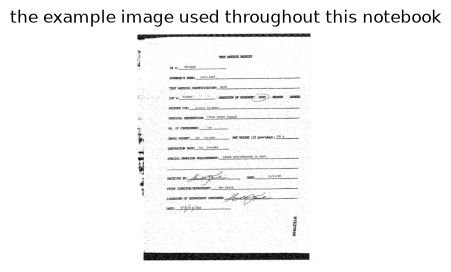

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

IMAGE_PATH = Path("assets/form_receipt.png")

image = cv2.imread(str(IMAGE_PATH), cv2.IMREAD_GRAYSCALE)

plt.rcParams["figure.figsize"] = (10, 3)
np.set_printoptions(precision=3, suppress=True)

plt.imshow(image, cmap="gray", vmin=0, vmax=255)
plt.axis("off")
plt.title("the example image used throughout this notebook")
plt.show()

## 1. Dilation and erosion, precisely

Work on a grayscale image $f: \Omega \to \{0, \dots, 255\}$ and a
*structuring element* $B$ — a small, fixed shape (a line, disk, or box)
with an origin.

**Dilation** replaces each pixel with the *maximum* of $f$ over the
neighborhood traced out by $B$:
$$(f \oplus B)(x) = \max_{b \in B} f(x - b)$$

**Erosion** is the dual, the *minimum*:
$$(f \ominus B)(x) = \min_{b \in B} f(x + b)$$

Dilation grows bright regions and shrinks dark ones; erosion does the
opposite. Combining them gives two more operations:

- **Opening** ($B$-erode then dilate): removes small bright features,
  keeps larger shapes roughly intact — good for estimating a
  slowly-varying background.
- **Closing** (dilate then erode): removes small dark features, fills
  small gaps.

## 2. The four operations, applied

A noisy scan shows these off well. Same structuring element throughout:
a 3x3 box.

In [2]:
kernel = np.ones((3, 3), dtype=np.uint8)
print(kernel)

[[1 1 1]
 [1 1 1]
 [1 1 1]]


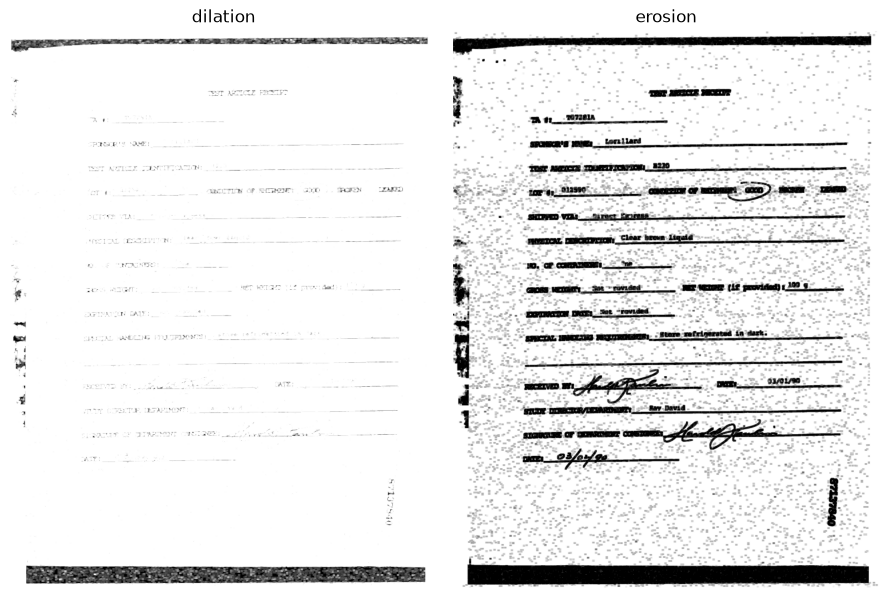

In [3]:
dilated = cv2.dilate(image, kernel)
eroded = cv2.erode(image, kernel)

fig, axes = plt.subplots(1, 2, figsize=(9, 11))
for ax, im, title in zip(axes, [dilated, eroded], ["dilation", "erosion"]):
    ax.imshow(im, cmap="gray", vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

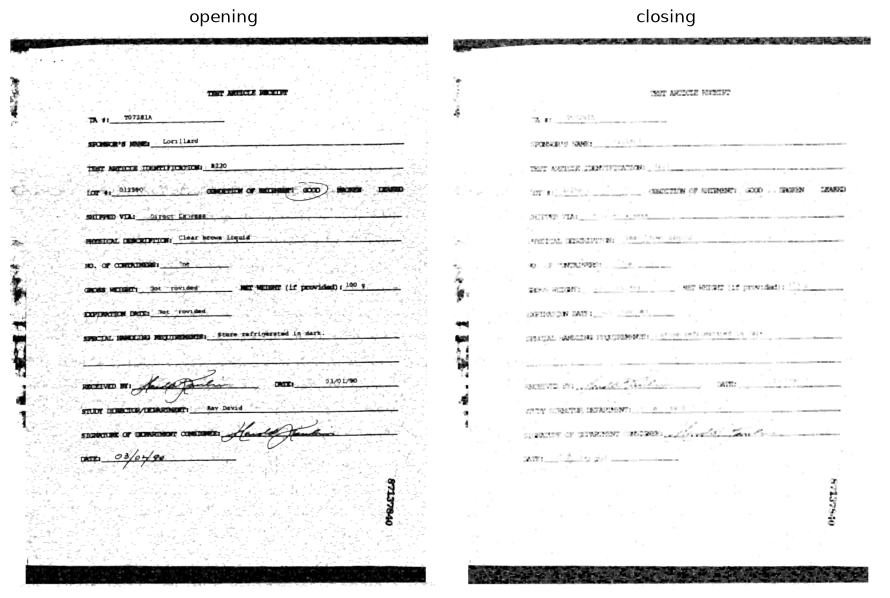

In [4]:
opened = cv2.morphologyEx(image, cv2.MORPH_OPEN, kernel)
closed = cv2.morphologyEx(image, cv2.MORPH_CLOSE, kernel)

fig, axes = plt.subplots(1, 2, figsize=(9, 11))
for ax, im, title in zip(axes, [opened, closed], ["opening", "closing"]):
    ax.imshow(im, cmap="gray", vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

Notice **opening** — it clears out almost all of the scan noise while
keeping the text and lines sharp. That's the operation the algorithm
in `algorithm_walkthrough.ipynb` uses to estimate a page's background.

## 3. Where this goes next

`algorithm_walkthrough.ipynb` uses exactly these two primitives — an
opening to estimate a page's background, then a thin-line dilation
(cleaned up with an erosion) to isolate its ruled lines.